# Notebook 03 — Feature Engineering

## Overview

We transform the raw, cleaned match data from `clean_matches.csv` into a set of
**powerful, predictive, normalised features** for downstream ML models.

### Why Feature Engineering?

Raw statistics have a fundamental problem: they **scale with game duration**.
A player who earned 15,000 gold in a 25-minute game is performing much better than
one who earned 15,000 gold in a 40-minute game. Without normalisation, our models
would confuse *game length* with *player performance*.

We address this by computing **per-minute rates** and **efficiency ratios**.

### Engineered Features

| Feature | Formula | Intuition |
|---------|---------|----------|
| `kda_ratio` | `(kills + assists) / max(deaths, 1)` | Combat efficiency — how many kills/assists per death |
| `gold_per_min` | `goldearned / (duration / 60)` | Economy efficiency — gold income rate |
| `damage_efficiency` | `totdmgtochamp / max(goldspent, 1)` | Damage output per gold invested |
| `kill_participation` | `(kills + assists) / team_total_kills` | Share of teamfights the player impacted |
| `vision_control` | `visionscore / (duration / 60)` | Ward placement rate per minute |
| `death_rate` | `deaths / (duration / 60)` | How often a player dies (lower is better) |
| `cs_per_min` | `(minions + neutrals) / (duration / 60)` | Farming rate — last-hitting skill |

### Output
A clean, ML-ready dataset: `data/processed/features_engineered.csv`
with **1.79M rows × 41 columns**, ready for XGBoost and scikit-learn.

## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

CLEAN_CSV  = '../data/processed/clean_matches.csv'
OUTPUT_CSV = '../data/processed/features_engineered.csv'

df = pd.read_csv(CLEAN_CSV)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from {CLEAN_CSV}")
display(df.head(2))

Loaded 1,786,568 rows and 31 columns from ../data/processed/clean_matches.csv


,id,matchid,player,champion_name,champion_classes,champion_role,champion_difficulty,role,position,win,...,wardsplaced,wardskilled,duration,team_id,firsttower,firstbaron,firstdragon,towerkills,dragonkills,baronkills
0,9,10,1,Warwick,Diver,"Jungle,Top",Novice,NONE,JUNGLE,0.0,...,10.0,0.0,1909,100,1,0,0,5,0,0
1,10,10,2,Nami,Enchanter,Support,Intermediate,DUO_SUPPORT,BOT,0.0,...,17.0,3.0,1909,100,1,0,0,5,0,0


## 1. Team-Level Aggregations

To calculate a player's **Kill Participation** (KP%), we first need to know how many
kills their *team as a whole* secured in that match.

We compute `team_total_kills` by grouping on `(matchid, team_id)` and summing individual kills.
Team IDs in this dataset are always `100` (Blue side) or `200` (Red side).

**Edge case:** If a team secured 0 kills (a mercy-rule scenario or extremely early surrender),
we clip to a minimum of 1 to avoid division-by-zero when computing kill participation.

In [2]:
# Group by match ID and team ID to sum total team kills
team_kills = df.groupby(['matchid', 'team_id'])['kills'].sum().reset_index()
team_kills.rename(columns={'kills': 'team_total_kills'}, inplace=True)

# Merge back to main dataframe
df = pd.merge(df, team_kills, on=['matchid', 'team_id'], how='left')

# Handle edge case: teams with 0 total kills to prevent division by zero
df['team_total_kills'] = df['team_total_kills'].clip(lower=1)

print("Sample of team kills calculation: ")
display(df[['matchid', 'team_id', 'player', 'kills', 'team_total_kills']].head(5))

Sample of team kills calculation: 


,matchid,team_id,player,kills,team_total_kills
0,10,100,1,6.0,20.0
1,10,100,2,0.0,20.0
2,10,100,3,7.0,20.0
3,10,100,4,5.0,20.0
4,10,100,5,2.0,20.0


## 2. Core Feature Engineering

We compute all 7 target metrics in a single cell using vectorised pandas operations for speed.
All division-by-zero cases are handled by `.clip(lower=1)` which replaces 0 denominators with 1.

| Formula Detail | Edge Case Handling |
|---------------|-------------------|
| `deaths.clip(lower=1)` | 0-death games → denominator = 1 (KDA = kills+assists) |
| `goldspent.clip(lower=1)` | 0 gold spent → damage_efficiency = raw damage (unusual but valid) |
| `team_total_kills.clip(lower=1)` | 0-kill teams → KP = 0 (applied in step 1) |
| `kill_participation.clip(upper=1.0)` | Data edge case: if player kills > team total (data quirk) |

After computing, we drop the 3 rows (~0.0001% of data) where `goldspent == NaN`.

In [3]:
dur_min = df['duration'] / 60  # Duration in minutes

# 1. KDA Ratio: (K+A)/D
df['kda_ratio'] = (df['kills'] + df['assists']) / df['deaths'].clip(lower=1)

# 2. Gold Per Minute
df['gold_per_min'] = df['goldearned'] / dur_min

# 3. Damage Efficiency (Damage per gold spent)
df['damage_efficiency'] = df['totdmgtochamp'] / df['goldspent'].clip(lower=1)

# 4. Kill Participation (Percentage of team kills involved in)
df['kill_participation'] = (df['kills'] + df['assists']) / df['team_total_kills']
# Cap at 1.0 (sometimes data quirks exist)
df['kill_participation'] = df['kill_participation'].clip(upper=1.0)

# 5. Vision Control per Minute
df['vision_control'] = df['visionscore'] / dur_min

# 6. Death Rate (Deaths per minute)
df['death_rate'] = df['deaths'] / dur_min

# 7. Creep Score per minute
df['cs_per_min'] = (df['totminionskilled'] + df['neutralminionskilled']) / dur_min

engineered_cols = [
    'kda_ratio', 'gold_per_min', 'damage_efficiency', 
    'kill_participation', 'vision_control', 'death_rate', 'cs_per_min'
]

# Drop the 3 edge-case rows with NaN
df.dropna(subset=engineered_cols, inplace=True)

print("Engineered Features Summary:")
display(df[engineered_cols].describe().round(3))

print("\nSample profiles:")
display(df[['win'] + engineered_cols].head(5).round(3))

Engineered Features Summary:


,kda_ratio,gold_per_min,damage_efficiency,kill_participation,vision_control,death_rate,cs_per_min
count,1786565.000,1786565.000,1786565.000,1786565.000,1786565.000,1786565.000,1786565.000
mean,3.539,371.899,1.613,0.482,0.445,0.189,4.612
std,3.686,72.546,0.967,0.155,0.512,0.093,2.292
min,0.000,126.566,0.000,0.000,0.000,0.000,0.000
25%,1.400,320.633,1.167,0.381,0.000,0.123,3.063
50%,2.400,367.794,1.563,0.486,0.361,0.185,5.005
75%,4.200,418.718,1.996,0.587,0.689,0.249,6.331
max,46.000,978.330,884.000,1.000,3.686,1.690,14.093



Sample profiles:


,win,kda_ratio,gold_per_min,damage_efficiency,kill_participation,vision_control,death_rate,cs_per_min
0,0.0,0.700,329.921,0.886,0.35,0.440,0.314,3.489
1,0.0,6.000,298.460,1.063,0.60,0.943,0.063,0.566
2,0.0,1.500,412.865,1.225,0.60,0.817,0.251,6.537
3,0.0,0.636,345.919,1.429,0.35,0.157,0.346,5.343
4,0.0,0.500,359.529,1.739,0.20,0.471,0.251,7.512


### 2.1 Visualise Engineered Feature Distributions

Before validating, let's visualise the distribution of each engineered feature,
split by `win` vs `loss`. A good feature should show **clear separation** between
the two groups — this indicates it will be informative for ML models.

- **Right-shifted distributions for winners** = feature is positively correlated with winning.
- **Left-shifted for winners** = negatively correlated (like `death_rate`).

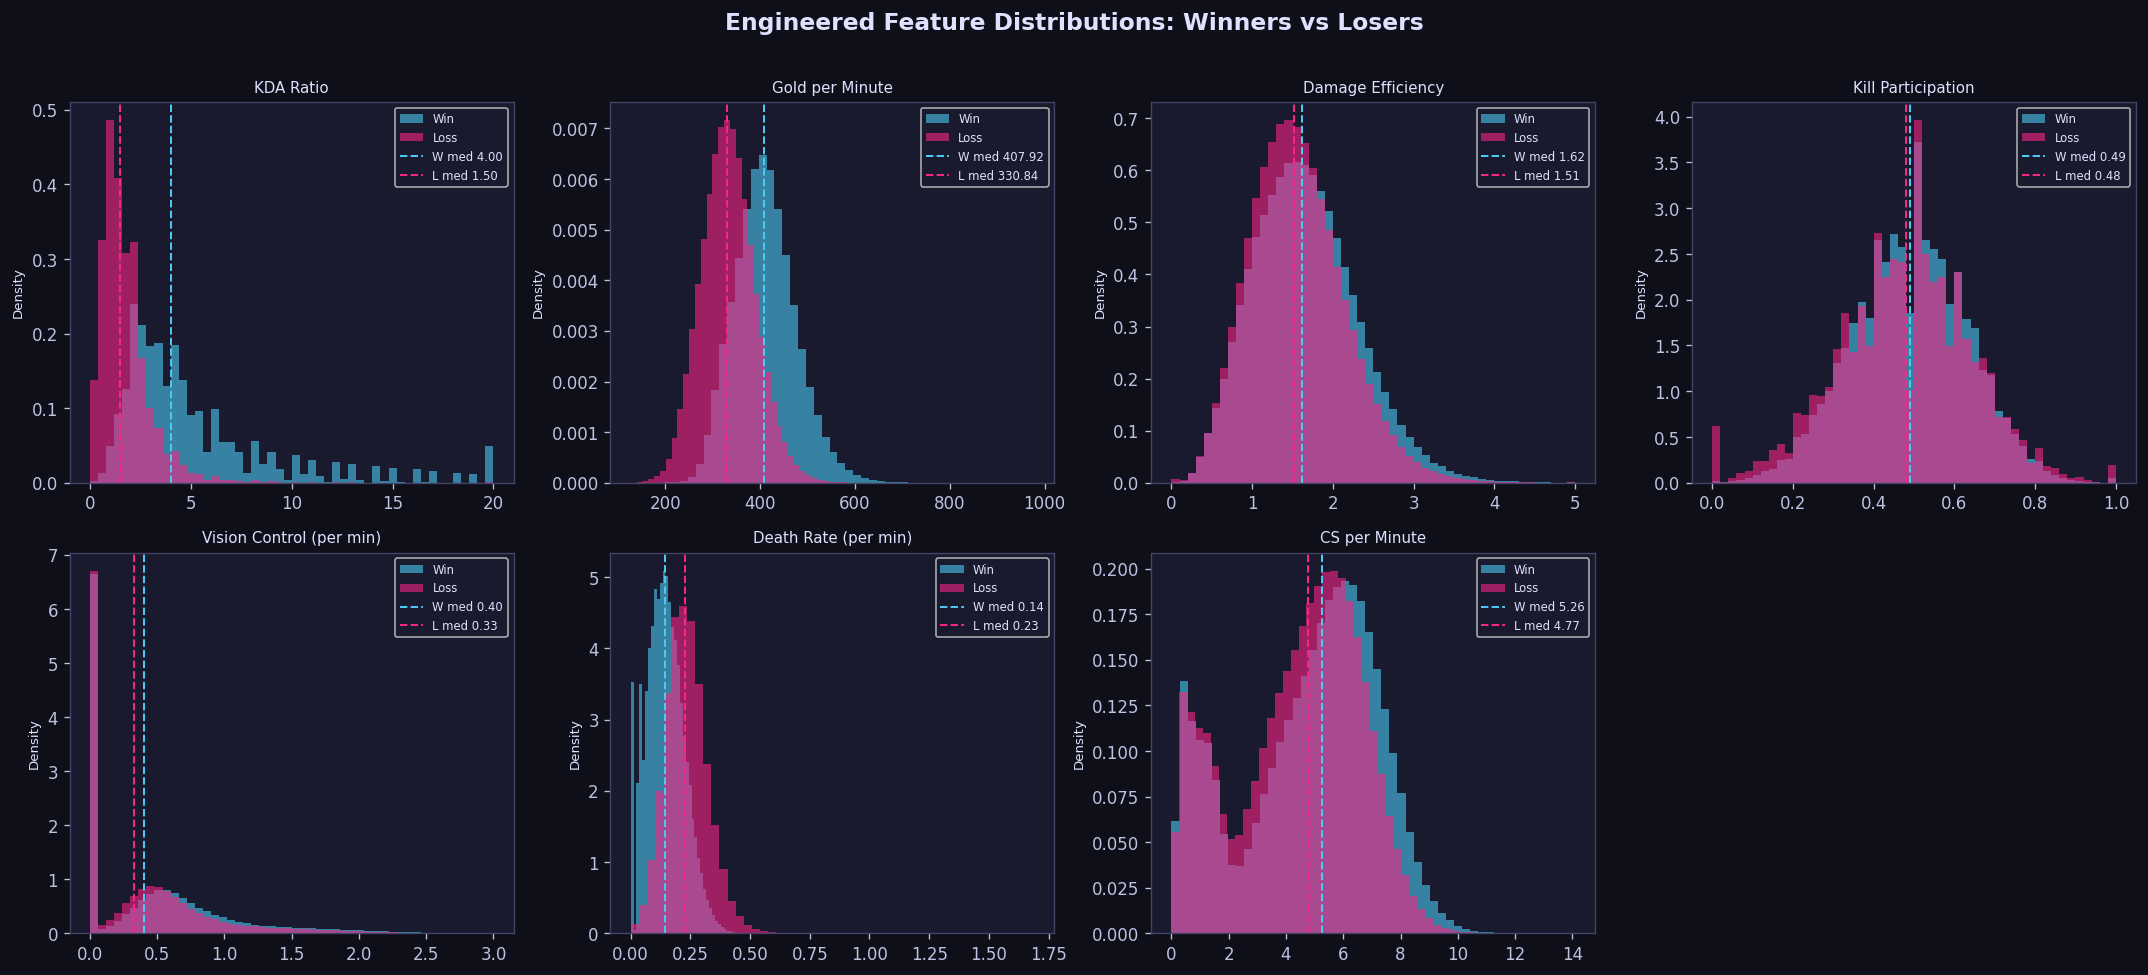

Saved: ../data/processed/eda_plots/10_engineered_feature_distributions.png

Plot shows distribution comparison for all 7 engineered features.


In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Style consistent with EDA notebook ────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444466',
    'axes.labelcolor'  : '#e0e0ff',
    'xtick.color'      : '#c0c0e0',
    'ytick.color'      : '#c0c0e0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'font.family'      : 'sans-serif',
    'figure.dpi'       : 120,
})
WIN_COL  = '#4cc9f0'   # blue
LOSS_COL = '#f72585'   # pink

PLOTS_DIR = '../data/processed/eda_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_fig(name):
    """Save figure to disk AND embed it inline in the notebook cell output."""
    import io
    from IPython.display import display, Image
    path = f'{PLOTS_DIR}/{name}.png'
    plt.savefig(path, bbox_inches='tight', facecolor=plt.gcf().get_facecolor())
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=plt.gcf().get_facecolor())
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close()
    print(f'Saved: {path}')

winners = df[df['win'] == 1]
losers  = df[df['win'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Engineered Feature Distributions: Winners vs Losers',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

features_plot = [
    ('kda_ratio',         'KDA Ratio',             20),
    ('gold_per_min',      'Gold per Minute',        None),
    ('damage_efficiency', 'Damage Efficiency',      5),
    ('kill_participation','Kill Participation',     None),
    ('vision_control',    'Vision Control (per min)', 3),
    ('death_rate',        'Death Rate (per min)',   None),
    ('cs_per_min',        'CS per Minute',          None),
]

for i, (feat, label, cap) in enumerate(features_plot):
    ax = axes[i]
    w_data = winners[feat].dropna()
    l_data = losers[feat].dropna()
    if cap:
        w_data = w_data.clip(upper=cap)
        l_data = l_data.clip(upper=cap)
    ax.hist(w_data, bins=50, alpha=0.6, color=WIN_COL,  label='Win',  density=True)
    ax.hist(l_data, bins=50, alpha=0.6, color=LOSS_COL, label='Loss', density=True)
    ax.axvline(w_data.median(), color=WIN_COL,  linestyle='--', linewidth=1.2,
               label=f'W med {w_data.median():.2f}')
    ax.axvline(l_data.median(), color=LOSS_COL, linestyle='--', linewidth=1.2,
               label=f'L med {l_data.median():.2f}')
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density', fontsize=8)

# Hide the unused 8th subplot
axes[7].set_visible(False)

plt.tight_layout()
save_fig('10_engineered_feature_distributions')
print('\nPlot shows distribution comparison for all 7 engineered features.')

## 3. Categorical Encoding

ML models require numeric inputs. We one-hot encode `role`, `position`, and parse out the first `champion_class` since Champions 2024.csv uses piped formats like "Mage|Support".

In [5]:
# 3.1 Map Champion Class (take the primary class only)
def extract_primary_class(c):
    if pd.isna(c) or c == 'Unknown': return 'Unknown'
    return str(c).split('|')[0]

df['primary_class'] = df['champion_classes'].apply(extract_primary_class)
print("Primary class distribution:")
print(df['primary_class'].value_counts())

# 3.2 One-Hot Encode
print("\nApplying One-Hot Encoding to role, position, and primary_class...")
cat_cols = ['role', 'position', 'primary_class']
ohe_df = pd.get_dummies(df[cat_cols], drop_first=False)

# Convert bools to int
for c in ohe_df.columns:
    ohe_df[c] = ohe_df[c].astype(int)

# Concatenate with main dataframe
df = pd.concat([df, ohe_df], axis=1)
print(f"\nAdded {ohe_df.shape[1]} dummy columns.")

Primary class distribution:
primary_class
Marksman               346827
Diver                  195997
Assassin               150716
Burst                  147744
Catcher                145907
Skirmisher             136077
Vanguard               132773
Specialist             112807
Enchanter               91862
Juggernaut              78641
Battlemage              68012
Warden                  48656
Artillery               34485
Burst  Artillery        26238
Burst  Enchanter        23344
Assassin  Diver         14681
Marksman  Catcher       13526
Marksman  Artillery      9457
Unknown                  5218
Enchanter  Warden        3597
Name: count, dtype: int64

Applying One-Hot Encoding to role, position, and primary_class...



Added 29 dummy columns.


## 4. Validation & Quality Checks

Ensure no `NaN` or `inf` values snuck into our dataset during division operations.

In [6]:
feature_set = engineered_cols + list(ohe_df.columns)

nulls = df[feature_set].isnull().sum()
print(f"Missing values: {nulls.sum()}")

infinities = np.isinf(df[engineered_cols].values).sum()
print(f"Infinity values: {infinities}")

assert nulls.sum() == 0, "NaNs found in features!"
assert infinities == 0, "Infinities found in features!"
print("\nValidation passed! All features are clean and bounded.")

Missing values: 0
Infinity values: 0

Validation passed! All features are clean and bounded.


## 5. Correlate New Features to Win

Did our feature engineering work? Let's check Pearson correlation to the target variable (`win`).

In [7]:
corr_win = df[['win'] + engineered_cols].corr()['win'].sort_values(ascending=False)

print("Pearson Correlation with 'win':")
for f, c in corr_win.items():
    if f == 'win': continue
    print(f"  {f:20} : {c:+.3f}")

Pearson Correlation with 'win':
  gold_per_min         : +0.543
  kda_ratio            : +0.485
  cs_per_min           : +0.086
  vision_control       : +0.063
  damage_efficiency    : +0.052
  kill_participation   : +0.049
  death_rate           : -0.469


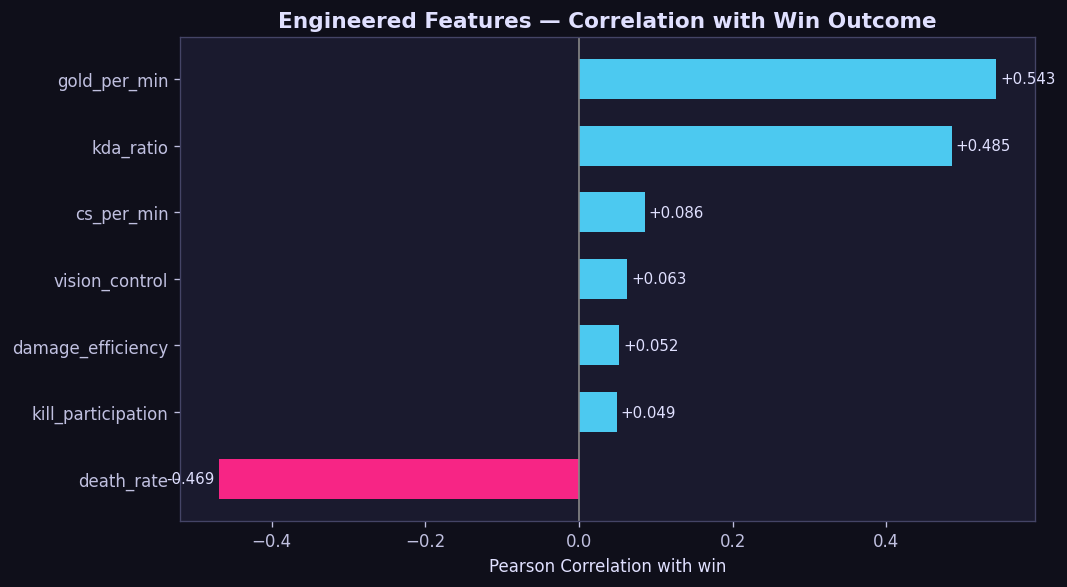

Saved: ../data/processed/eda_plots/11_feature_correlation_with_win.png

> gold_per_min and kda_ratio are the two strongest predictors.


In [8]:
# Bar chart of feature correlations with win
# (reuse the style and save_fig already defined in dist_plot cell)
import numpy as np

corr_df = corr_win.drop('win').sort_values()
colors = [WIN_COL if v > 0 else LOSS_COL for v in corr_df.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_df.index, corr_df.values, color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='#888', linewidth=1)
ax.set_xlabel('Pearson Correlation with win')
ax.set_title('Engineered Features — Correlation with Win Outcome',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, corr_df.values):
    x_offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + x_offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9, color='#e0e0ff')

plt.tight_layout()
save_fig('11_feature_correlation_with_win')
print('\n> gold_per_min and kda_ratio are the two strongest predictors.')

### Interpretation: Feature Correlations with Win

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| `gold_per_min` | +0.543 | **Strongest predictor** — economy wins games |
| `kda_ratio` | +0.485 | Second strongest — staying alive and getting kills |
| `death_rate` | -0.469 | Dying frequently is strongly associated with losing |
| `cs_per_min` | +0.086 | Moderate — good farming helps but isn't decisive alone |
| `vision_control` | +0.063 | Positive association — warding matters |
| `damage_efficiency` | +0.052 | Weaker signal — raw damage doesn't always win games |
| `kill_participation` | +0.049 | Weakest here — KP is spread across all team members |

**Key insight:** The trio of `gold_per_min`, `kda_ratio`, and `death_rate` captures
the vast majority of the predictive signal from individual player performance.
These three features alone would form a competitive baseline model.

## 6. Select Final Features & Save

We select the final column set for the ML-ready output file:

- **Identity columns:** `id`, `matchid`, `player`, `champion_name` — for traceability.
- **Target variable:** `win` — what we're trying to predict.
- **Engineered features:** 7 normalised metrics computed above.
- **One-hot encoded columns:** 29 dummy variables for `role`, `position`, and `primary_class`.

Raw columns (`kills`, `deaths`, `goldearned`, etc.) are dropped to prevent target leakage
and redundancy. The `duration` column is dropped since it's a confound.

**Total: 41 columns, 1,786,565 rows (~337 MB)**

In [9]:
final_cols = ['id', 'matchid', 'player', 'champion_name', 'win'] + feature_set
df_out = df[final_cols]

df_out.to_csv(OUTPUT_CSV, index=False)

size_mb = os.path.getsize(OUTPUT_CSV) / (1024**2)
print(f"\nSaved features to: {os.path.abspath(OUTPUT_CSV)}")
print(f"Dataset shape    : {df_out.shape[0]:,} rows x {df_out.shape[1]} columns")
print(f"File size        : {size_mb:.1f} MB")


Saved features to: C:\Users\asus\rift-analytics\data\processed\features_engineered.csv
Dataset shape    : 1,786,565 rows x 41 columns
File size        : 337.9 MB
